# Crypto Price Forecast - Analysis & Visualization
This notebook is used for importing data and models from the src package, analyzing the data, and visualizing the results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data
from src.data import engineer_features

In [2]:
# Load data
df = load_data('data/crypto_statistics_data.csv')
df.head()

,name,symbol,crypto,date,network,open,high,low,close,average,range,pct_change
0,Cardano,ADA,ADA/USD,2018-08-01,Cardano,0.14152,0.14474,0.13500,0.13984,0.140275,0.00974,NaN
1,Cardano,ADA,ADA/USD,2018-08-02,Cardano,0.13983,0.14149,0.12850,0.13039,0.135052,0.01299,-0.067577
2,Cardano,ADA,ADA/USD,2018-08-03,Cardano,0.13079,0.13473,0.12290,0.12947,0.129472,0.01183,-0.007056
3,Cardano,ADA,ADA/USD,2018-08-04,Cardano,0.12941,0.13358,0.12353,0.12639,0.128227,0.01005,-0.023789
4,Cardano,ADA,ADA/USD,2018-08-05,Cardano,0.12622,0.13130,0.12440,0.13024,0.128040,0.00690,0.030461


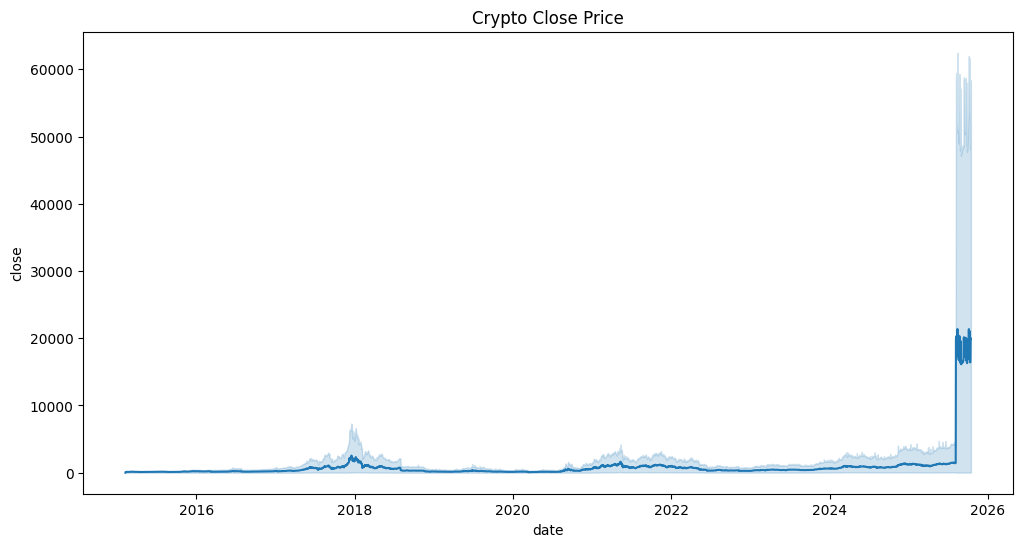

In [3]:
# Plotting Close Price over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='close')
plt.title('Crypto Close Price')
plt.show()

In [4]:
# Reproducibility and imports
import os, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"numpy {np.__version__}, pandas {pd.__version__}, tensorflow {tf.__version__}")

numpy 2.4.3, pandas 3.0.2, tensorflow 2.21.0


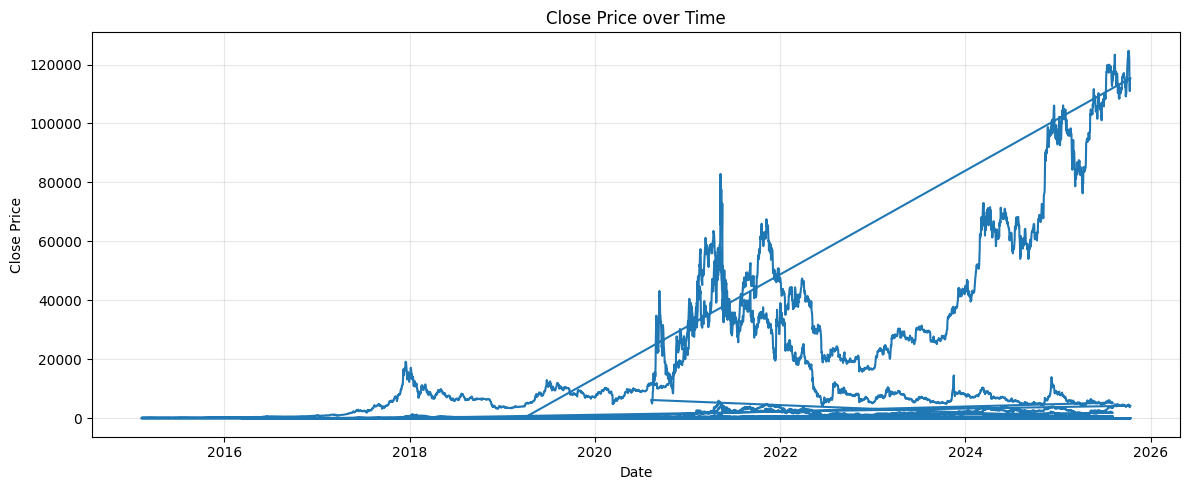

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['close'], linewidth=1.5)
plt.title('Close Price over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

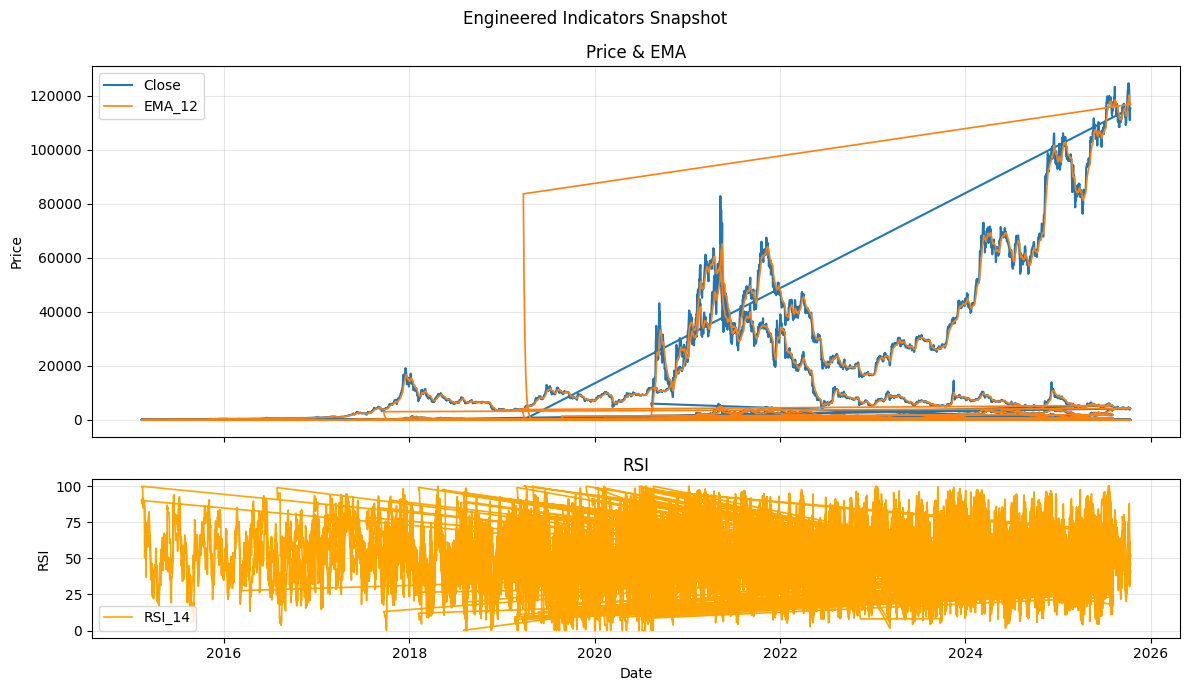

In [ ]:
# Feature engineering snapshot and indicators
eng = engineer_features(df.copy())
cols = ['date', 'close']
if 'EMA_12' in eng.columns:
    ema = 'EMA_12'
else:
    ema = [c for c in eng.columns if 'EMA' in c][:1]
if isinstance(ema, list):
    ema = ema[0] if ema else None

rsi_col = 'RSI_14' if 'RSI_14' in eng.columns else None
macd_col = 'MACD' if 'MACD' in eng.columns else None

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [0.7, 0.3]})
axes[0].plot(eng['date'], eng['close'], label='Close', linewidth=1.5)
if ema:
    axes[0].plot(eng['date'], eng[ema], label=ema, linewidth=1.2)
axes[0].set_title('Price & EMA')
axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.3)
axes[0].legend()

if rsi_col:
    axes[1].plot(eng['date'], eng[rsi_col], label=rsi_col, color='orange', linewidth=1.2)
    axes[1].legend()
axes[1].set_title('RSI')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('RSI')
axes[1].grid(alpha=0.3)

fig.suptitle('Engineered Indicators Snapshot')
plt.tight_layout()
plt.show()

In [7]:
# Preprocessing, scaling, and sequence preview
series = eng['close'].values.reshape(-1,1)
split = int(len(series)*0.8)
train, test = series[:split], series[split:]

scaler = MinMaxScaler()
train_s = scaler.fit_transform(train)
test_s = scaler.transform(test)

LOOKBACK = 30
def make_sequence(arr, lookback):
	X, y = [], []
	for i in range(len(arr)-lookback):
		X.append(arr[i:i+lookback,0])
		y.append(arr[i+lookback,0])
	return np.array(X), np.array(y)

X_train, y_train = make_sequence(train_s, LOOKBACK)
X_test, y_test = make_sequence(np.vstack([train_s[-LOOKBACK:], test_s]), LOOKBACK)

print('Train shapes:', X_train.shape, y_train.shape)
print('Test shapes:', X_test.shape, y_test.shape)

Train shapes: (166018, 30) (166018,)
Test shapes: (41513, 30) (41513,)


In [8]:
# Load saved models and compare on test set
from tensorflow.keras.models import load_model
results = []

for name, path in [('LSTM','results/lstm_model.keras'), ('GRU','results/gru_model.keras')]:
	try:
		m = load_model(path)
		# prepare X_test in model input shape (samples, lookback, 1)
		X_in = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
		preds_s = m.predict(X_in, verbose=0).ravel()
		preds = scaler.inverse_transform(preds_s.reshape(-1,1)).ravel()
		y_true = scaler.inverse_transform(y_test.reshape(-1,1)).ravel()
		rmse = float(np.sqrt(mean_squared_error(y_true, preds)))
		mae = mean_absolute_error(y_true, preds)
		mape = (np.mean(np.abs((y_true - preds) / y_true)))*100
		results.append({'model':name, 'rmse':rmse, 'mae':mae, 'mape':mape})
	except Exception as e:
		print(f"Could not load {name} at {path}: {e}")

if results:
	res_df = pd.DataFrame(results).sort_values('rmse')
	display(res_df)
else:
	print('No models loaded; ensure results/*.keras exist.')

Could not load LSTM at results/lstm_model.keras: File not found: filepath=results/lstm_model.keras. Please ensure the file is an accessible `.keras` zip file.
Could not load GRU at results/gru_model.keras: File not found: filepath=results/gru_model.keras. Please ensure the file is an accessible `.keras` zip file.
No models loaded; ensure results/*.keras exist.


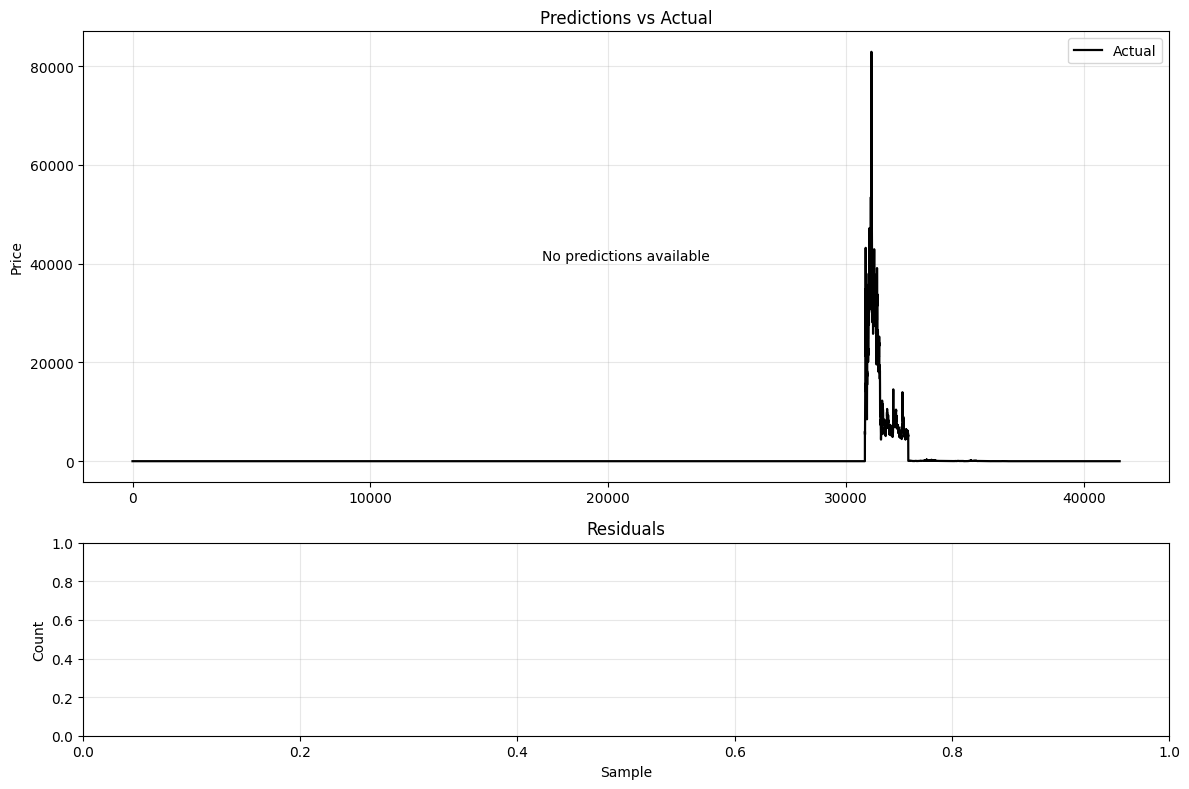

In [9]:
# Predictions vs Actual and residuals visualization
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [0.7, 0.3]})

# combine predictions if available
pred_dfs = {}
for name, path in [('LSTM', 'results/lstm_model.keras'), ('GRU', 'results/gru_model.keras')]:
    try:
        m = load_model(path)
        X_in = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
        preds_s = m.predict(X_in, verbose=0).ravel()
        preds = scaler.inverse_transform(preds_s.reshape(-1, 1)).ravel()
        pred_dfs[name] = preds
        axes[0].plot(preds, label=f'{name} Pred', linewidth=1.2)
    except:
        pass

# actual
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
axes[0].plot(y_true, label='Actual', color='black', linewidth=1.6)
axes[0].set_title('Predictions vs Actual')
axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.3)

# residuals histogram for best model if exists
if pred_dfs:
    best = min(pred_dfs.keys(), key=lambda k: float(np.sqrt(mean_squared_error(y_true, pred_dfs[k]))))
    res = y_true - pred_dfs[best]
    axes[1].hist(res, bins=40, alpha=0.75, edgecolor='white')

    # uncertainty band (mean +/- std across models)
    preds_stack = np.vstack(list(pred_dfs.values()))
    mean_pred = preds_stack.mean(axis=0)
    std_pred = preds_stack.std(axis=0)
    x = np.arange(len(mean_pred))
    axes[0].fill_between(x, mean_pred - std_pred, mean_pred + std_pred, alpha=0.2, label='Uncertainty band')
else:
    axes[0].text(0.5, 0.5, 'No predictions available', transform=axes[0].transAxes, ha='center', va='center')

axes[1].set_title('Residuals')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)
axes[0].legend()

plt.tight_layout()
plt.show()